In [1]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

--2025-11-11 21:51:02--  https://fem-on-colab.github.io/releases/fenics-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4180 (4.1K) [application/x-sh]
Saving to: ‘/tmp/fenics-install.sh’

/tmp/fenics-install 100%[===================>]   4.08K  --.-KB/s    in 0s      

2025-11-11 21:51:02 (32.4 MB/s) - ‘/tmp/fenics-install.sh’ saved [4180/4180]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICS_INSTALLED=/usr/local/share/fem-on-colab/fenics.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenics.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/1f62c6f6/releases/pybi

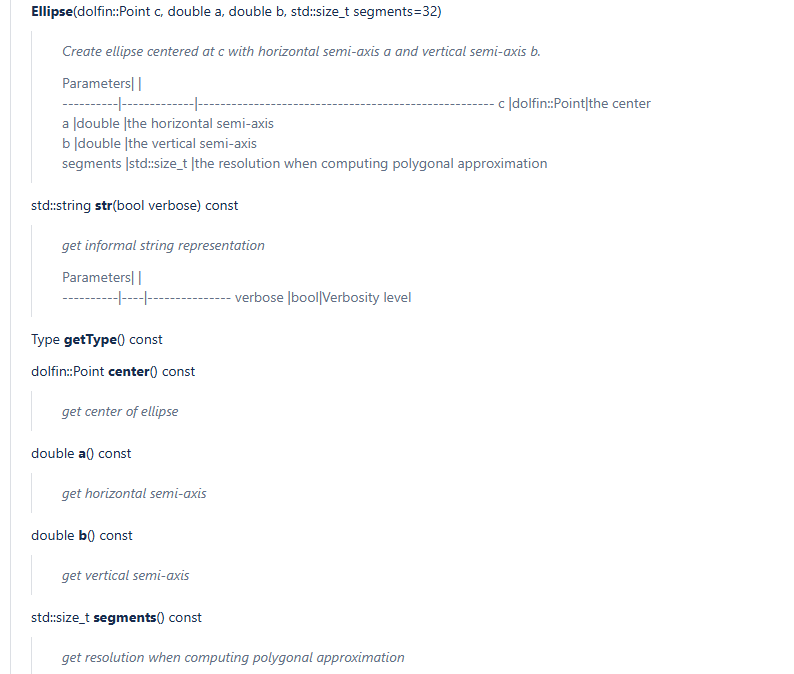

In [2]:
from fenics import *
from __future__ import print_function
from dolfin import *
from mshr import *
import matplotlib.pyplot as plt
%matplotlib inline

# Implementação ChatGPT

EXEMPLOS DE PROBLEMAS COM CONDIÇÕES DE NEUMANN USANDO FENICS

=== Problema com Condições Mistas (Dirichlet + Neumann) ===



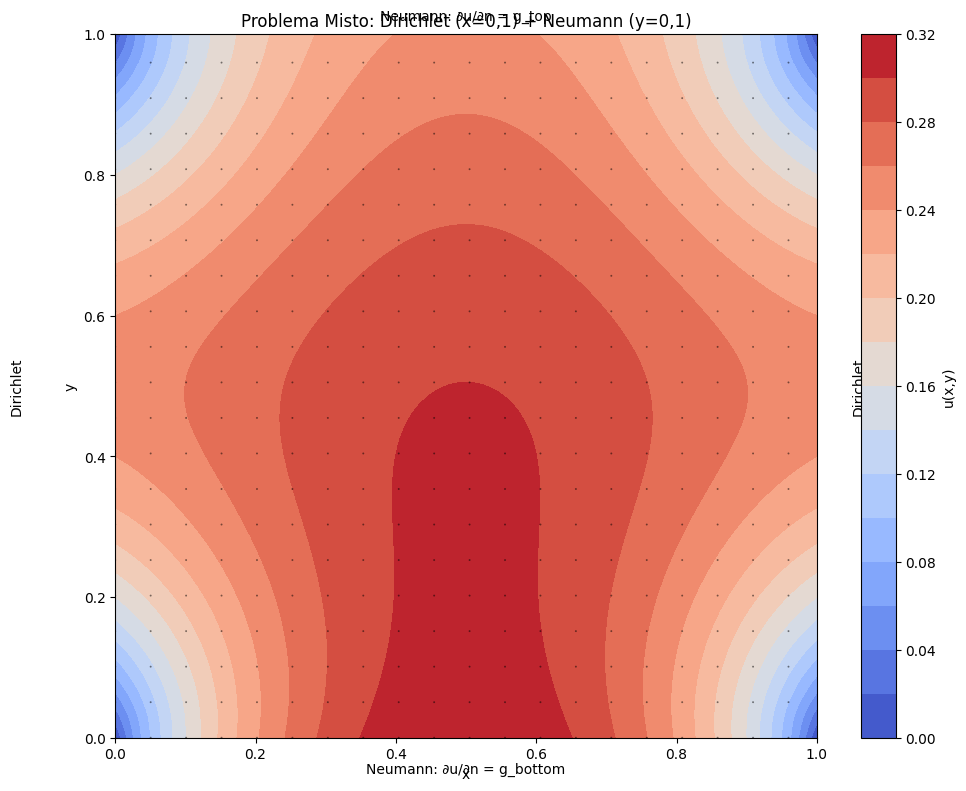


Todos os exemplos foram executados com sucesso!


In [ ]:
"""
Resolução de Problemas de Valor de Contorno com Condições de Neumann usando FEniCS

Instalação do FEniCS:
---------------------
# Opção 1: Usando conda (recomendado)
conda create -n fenics
conda activate fenics
conda install -c conda-forge fenics

# Opção 2: Usando Docker
docker run -ti -v $(pwd):/home/fenics/shared quay.io/fenicsproject/stable

# Opção 3: Usando apt (Ubuntu/Debian)
sudo apt-get install fenics
"""

from fenics import *
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configurar para não exibir logs desnecessários
set_log_level(LogLevel.WARNING)

def solve_1d_neumann():
    """
    Resolve -u''(x) = f(x) em [0, 1]
    com u'(0) = g_L e u'(1) = g_R
    """
    print("=== Problema 1D com Condições de Neumann ===\n")

    # Criar malha 1D
    mesh = IntervalMesh(100, 0, 1)

    # Definir espaço de elementos finitos (P1 = polinômios lineares)
    V = FunctionSpace(mesh, 'P', 1)

    # Definir as condições de Neumann
    g_L = Constant(0.0)  # u'(0) = 0
    g_R = Constant(0.0)  # u'(1) = 0

    # Definir termo fonte
    f = Expression('sin(2*pi*x[0])', degree=2)

    # Definir a solução teste e trial
    u = TrialFunction(V)
    v = TestFunction(V)

    # Formulação variacional
    # ∫ ∇u·∇v dx = ∫ f·v dx + ∫_∂Ω g·v ds
    a = dot(grad(u), grad(v))*dx
    L = f*v*dx

    # Adicionar termos de Neumann nas fronteiras
    # Definir as fronteiras
    def boundary_left(x, on_boundary):
        return on_boundary and near(x[0], 0.0)

    def boundary_right(x, on_boundary):
        return on_boundary and near(x[0], 1.0)

    # Criar medidas para integração nas fronteiras
    boundary_markers = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)

    class LeftBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return boundary_left(x, on_boundary)

    class RightBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return boundary_right(x, on_boundary)

    left = LeftBoundary()
    right = RightBoundary()

    left.mark(boundary_markers, 1)
    right.mark(boundary_markers, 2)

    # Redefinir medida ds para usar marcadores
    ds = Measure('ds', domain=mesh, subdomain_data=boundary_markers)

    # Adicionar condições de Neumann ao funcional linear
    L = f*v*dx + g_L*v*ds(1) + g_R*v*ds(2)

    # Como temos apenas condições de Neumann, precisamos fixar um ponto
    # para garantir unicidade. Vamos impor u(0.5) = 0

    # Criar uma condição de Dirichlet em um único ponto
    def midpoint(x, on_boundary):
        return near(x[0], 0.5)

    bc = DirichletBC(V, Constant(0.0), midpoint, method='pointwise')

    # Resolver o sistema
    u = Function(V)
    solve(a == L, u, bc)

    # Plotar solução
    plt.figure(figsize=(12, 5))

    # Extrair valores para plotagem
    x_vals = mesh.coordinates()[:, 0]
    u_vals = u.compute_vertex_values()

    # Ordenar por x (necessário para plotagem correta)
    idx = np.argsort(x_vals)
    x_vals = x_vals[idx]
    u_vals = u_vals[idx]

    plt.subplot(1, 2, 1)
    plt.plot(x_vals, u_vals, 'b-', linewidth=2, label='Solução u(x)')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.title('Solução 1D com Condições de Neumann (FEniCS)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Calcular e plotar derivada
    V_grad = FunctionSpace(mesh, 'P', 1)
    u_grad = project(grad(u)[0], V_grad)
    grad_vals = u_grad.compute_vertex_values()[idx]

    plt.subplot(1, 2, 2)
    plt.plot(x_vals, grad_vals, 'r-', linewidth=2, label="u'(x)")
    plt.axhline(y=float(g_L), color='g', linestyle='--', label=f"u'(0) = {float(g_L)}")
    plt.axhline(y=float(g_R), color='g', linestyle='--', label=f"u'(1) = {float(g_R)}")
    plt.xlabel('x')
    plt.ylabel("u'(x)")
    plt.title('Verificação das Condições de Neumann')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return u

def solve_2d_neumann():
    """
    Resolve -∆u = f em Ω = [0,1]×[0,1]
    com ∂u/∂n = g em toda a fronteira
    """
    print("\n=== Problema 2D com Condições de Neumann ===\n")

    # Criar malha 2D
    mesh = RectangleMesh(Point(0, 0), Point(1, 1), 30, 30)

    # Espaço de elementos finitos
    V = FunctionSpace(mesh, 'P', 1)

    # Termo fonte
    f = Expression('2*sin(pi*x[0])*sin(pi*x[1])', degree=2)

    # Condições de Neumann em cada parte da fronteira
    g_left = Constant(0.0)   # ∂u/∂n = 0 em x=0
    g_right = Constant(0.0)  # ∂u/∂n = 0 em x=1
    g_bottom = Constant(0.0) # ∂u/∂n = 0 em y=0
    g_top = Constant(0.0)    # ∂u/∂n = 0 em y=1

    # Marcar diferentes partes da fronteira
    boundary_markers = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)

    class LeftBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and near(x[0], 0.0)

    class RightBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and near(x[0], 1.0)

    class BottomBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and near(x[1], 0.0)

    class TopBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and near(x[1], 1.0)

    # Marcar fronteiras
    LeftBoundary().mark(boundary_markers, 1)
    RightBoundary().mark(boundary_markers, 2)
    BottomBoundary().mark(boundary_markers, 3)
    TopBoundary().mark(boundary_markers, 4)

    # Definir medida de integração na fronteira
    ds = Measure('ds', domain=mesh, subdomain_data=boundary_markers)

    # Formulação variacional
    u = TrialFunction(V)
    v = TestFunction(V)

    a = dot(grad(u), grad(v))*dx
    L = f*v*dx + g_left*v*ds(1) + g_right*v*ds(2) + g_bottom*v*ds(3) + g_top*v*ds(4)

    # Fixar um ponto para unicidade (centro do domínio)
    def center(x, on_boundary):
        return near(x[0], 0.5) and near(x[1], 0.5)

    bc = DirichletBC(V, Constant(0.0), center, method='pointwise')

    # Resolver
    u = Function(V)
    solve(a == L, u, bc)

    # Plotar solução
    fig = plt.figure(figsize=(14, 6))

    # Extrair dados para plotagem
    x = mesh.coordinates()[:, 0]
    y = mesh.coordinates()[:, 1]
    u_vals = u.compute_vertex_values()

    # Criar grade regular para plotagem
    from scipy.interpolate import griddata
    xi = np.linspace(0, 1, 100)
    yi = np.linspace(0, 1, 100)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), u_vals, (Xi, Yi), method='cubic')

    # Contour plot
    ax1 = fig.add_subplot(1, 2, 1)
    contour = ax1.contourf(Xi, Yi, Zi, levels=20, cmap='viridis')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('Solução 2D com Condições de Neumann (FEniCS)')
    plt.colorbar(contour, ax=ax1, label='u(x,y)')

    # 3D surface plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf = ax2.plot_surface(Xi, Yi, Zi, cmap='viridis', alpha=0.9)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('u(x,y)')
    ax2.set_title('Visualização 3D')
    plt.colorbar(surf, ax=ax2, shrink=0.5)

    plt.tight_layout()
    plt.show()

    return u

def solve_mixed_boundary():
    """
    Exemplo com condições mistas: Dirichlet em parte da fronteira,
    Neumann no resto
    """
    print("\n=== Problema com Condições Mistas (Dirichlet + Neumann) ===\n")

    # Criar malha
    mesh = UnitSquareMesh(40, 40)
    V = FunctionSpace(mesh, 'P', 1)

    # Definir partes da fronteira
    def dirichlet_boundary(x, on_boundary):
        # Dirichlet em x=0 e x=1
        return on_boundary and (near(x[0], 0.0) or near(x[0], 1.0))

    # Condição de Dirichlet
    u_D = Expression('x[1]*(1-x[1])', degree=2)
    bc = DirichletBC(V, u_D, dirichlet_boundary)

    # Termo fonte
    f = Constant(1.0)

    # Condições de Neumann em y=0 e y=1
    g_bottom = Expression('0.5*x[0]*(1-x[0])', degree=2)  # Fluxo não-zero
    g_top = Expression('-0.5*x[0]*(1-x[0])', degree=2)    # Fluxo oposto

    # Marcar fronteiras para Neumann
    boundary_markers = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)

    class BottomBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and near(x[1], 0.0)

    class TopBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and near(x[1], 1.0)

    BottomBoundary().mark(boundary_markers, 1)
    TopBoundary().mark(boundary_markers, 2)

    ds = Measure('ds', domain=mesh, subdomain_data=boundary_markers)

    # Formulação variacional
    u = TrialFunction(V)
    v = TestFunction(V)

    a = dot(grad(u), grad(v))*dx
    L = f*v*dx + g_bottom*v*ds(1) + g_top*v*ds(2)

    # Resolver
    u = Function(V)
    solve(a == L, u, bc)

    # Plotar
    plt.figure(figsize=(10, 8))

    # Preparar dados
    x = mesh.coordinates()[:, 0]
    y = mesh.coordinates()[:, 1]
    u_vals = u.compute_vertex_values()

    from scipy.interpolate import griddata
    xi = np.linspace(0, 1, 100)
    yi = np.linspace(0, 1, 100)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), u_vals, (Xi, Yi), method='cubic')

    # Plotar solução
    contour = plt.contourf(Xi, Yi, Zi, levels=20, cmap='coolwarm')
    plt.colorbar(contour, label='u(x,y)')

    # Adicionar setas indicando fluxo (gradiente)
    skip = 5
    U = np.gradient(Zi, axis=1)[::skip, ::skip]
    V = np.gradient(Zi, axis=0)[::skip, ::skip]
    plt.quiver(Xi[::skip, ::skip], Yi[::skip, ::skip], U, V,
               alpha=0.5, color='black', scale=20)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Problema Misto: Dirichlet (x=0,1) + Neumann (y=0,1)')

    # Adicionar anotações
    plt.text(0.5, -0.05, 'Neumann: ∂u/∂n = g_bottom', ha='center', transform=plt.gca().transAxes)
    plt.text(0.5, 1.02, 'Neumann: ∂u/∂n = g_top', ha='center', transform=plt.gca().transAxes)
    plt.text(-0.15, 0.5, 'Dirichlet', rotation=90, va='center', transform=plt.gca().transAxes)
    plt.text(1.05, 0.5, 'Dirichlet', rotation=90, va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

    return u

def solve_nonlinear_neumann():
    """
    Exemplo de problema não-linear com condições de Neumann
    -∇·(k(u)∇u) = f com k(u) = 1 + u²
    """
    print("\n=== Problema Não-Linear com Condições de Neumann ===\n")

    mesh = UnitSquareMesh(32, 32)
    V = FunctionSpace(mesh, 'P', 1)

    # Condição inicial
    u = Function(V)
    v = TestFunction(V)

    # Coeficiente não-linear
    def k(u):
        return 1 + u**2

    # Termo fonte
    f = Constant(1.0)

    # Condições de Neumann (zero em toda fronteira)
    g = Constant(0.0)

    # Formulação variacional não-linear
    F = k(u)*dot(grad(u), grad(v))*dx - f*v*dx - g*v*ds

    # Fixar um ponto para unicidade
    def center(x, on_boundary):
        return near(x[0], 0.5) and near(x[1], 0.5)

    bc = DirichletBC(V, Constant(0.0), center, method='pointwise')

    # Resolver problema não-linear
    solve(F == 0, u, bc)

    # Plotar
    plt.figure(figsize=(12, 5))

    # Preparar dados
    x = mesh.coordinates()[:, 0]
    y = mesh.coordinates()[:, 1]
    u_vals = u.compute_vertex_values()

    from scipy.interpolate import griddata
    xi = np.linspace(0, 1, 100)
    yi = np.linspace(0, 1, 100)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), u_vals, (Xi, Yi), method='cubic')

    # Contour plot
    plt.subplot(1, 2, 1)
    contour = plt.contourf(Xi, Yi, Zi, levels=20, cmap='plasma')
    plt.colorbar(contour, label='u(x,y)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Solução do Problema Não-Linear')

    # Plot do coeficiente k(u)
    plt.subplot(1, 2, 2)
    k_vals = 1 + u_vals**2
    Ki = griddata((x, y), k_vals, (Xi, Yi), method='cubic')
    contour2 = plt.contourf(Xi, Yi, Ki, levels=20, cmap='viridis')
    plt.colorbar(contour2, label='k(u) = 1 + u²')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Coeficiente de Difusão k(u)')

    plt.tight_layout()
    plt.show()

    return u

# Executar exemplos
if __name__ == "__main__":
    print("=" * 60)
    print("EXEMPLOS DE PROBLEMAS COM CONDIÇÕES DE NEUMANN USANDO FENICS")
    print("=" * 60)

    # Exemplo 1D
    # u_1d = solve_1d_neumann()

    # Exemplo 2D
    # u_2d = solve_2d_neumann()

    # Exemplo com condições mistas
    u_mixed = solve_mixed_boundary()

    # Exemplo não-linear
    # u_nonlinear = solve_nonlinear_neumann()

    print("\n" + "=" * 60)
    print("Todos os exemplos foram executados com sucesso!")
    print("=" * 60)

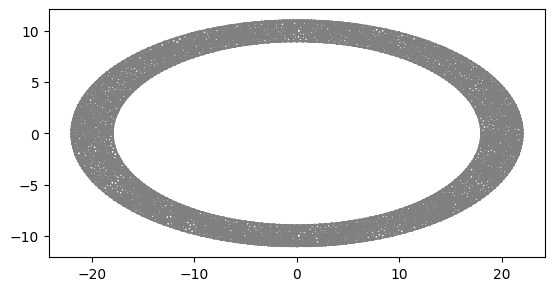

In [ ]:
# a,b = Dimensões dos semi-eixos das ellipses
a = 11.
b = 9.

# Criação do domínio pela função Ellipse do módulo meshr
# Poderíamos retirar parte do domínio para simplicação

# rect = Rectangle(Point(0., 0.), Point(a, a))
domain = Ellipse(Point(0., 0.), 2*a, a, 100) - Ellipse(Point(0., 0.), 2*b, b, 100)
# domain = domain - Rectangle(Point(0., -a), Point(-2*a, a)) \
#                  - Rectangle(Point(0., 0.), Point(2*a, -a))

mesh = generate_mesh(domain, 60)
plot(mesh)

# a,b = Dimensões dos semi-eixos das ellipses
a = 11.
b = 9.

# Criação do domínio pela função Ellipse do módulo meshr
# Poderíamos retirar parte do domínio para simplicação

# rect = Rectangle(Point(0., 0.), Point(a, a))
domain = Ellipse(Point(0., 0.), 2*a, a, 100) - Ellipse(Point(0., 0.), 2*b, b, 100)
domain = domain - Rectangle(Point(0., -a), Point(-2*a, a)) \
                 - Rectangle(Point(0., 0.), Point(2*a, -a))

mesh = generate_mesh(domain, 60)
plot(mesh)

class EllipseTop(SubDomain):
    def __init__(self, a, b):
        self.a = a**2
        self.b = b**2
        super().__init__()
    def inside(self, x, on_boundary):
        return on_boundary and near((x[0]**2/self.a)+(x[1]**2/self.b)-1., 0., eps= 1.e-12) and x[1] >= 0.

facets = MeshFunction("size_t", mesh, 1)
facets.set_all(0)
# Bottom().mark(facets, 1)
# Left().mark(facets, 2)
# Outer().mark(facets, 3)

facets = MeshFunction("size_t", mesh, 1)
facets.set_all(0)

EllipseTop(2*a, a).mark(facets, 1)
EllipseTop(2*b, b).mark(facets, 2)
ds = Measure("ds", subdomain_data=facets)


# Bottom().mark(facets, 1)
# Left().mark(facets, 2)
# Outer().mark(facets, 3)

In [ ]:
# Definindo as coordenadas espaciais e o tensor de deformação

x = SpatialCoordinate(mesh)

# Definindo os tensores de tensão e deformação
def epsilon(u):
    return 0.5*(nabla_grad(u) + nabla_grad(u).T)
    #return sym(nabla_grad(u))

E = Constant(1e5)
nu = Constant(0.3)
mu = E/2/(1+nu)
lmbda = E*nu/(1+nu)/(1-2*nu)
def sigma(v):
    return lmbda*tr(eps(v))*Identity(3) + 2.0*mu*eps(v)

In [ ]:
n = FacetNormal(mesh) # Campo vetorial normal às superfícies definidas
p = Constant(10.) # Pressão

V = VectorFunctionSpace(mesh, 'CG', degree=2)
du = TrialFunction(V)
u_ = TestFunction(V)
a = inner(sigma(du), eps(u_))*dx
l = inner(-p*n, u_)*ds(2)

u = Function(V, name="Displacement")

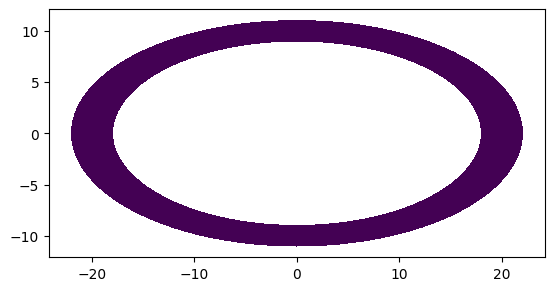

In [ ]:
plt.figure()
plot(100*u, mode="displacement")
plt.show()

# Simulação de um vaso de pressão cilindrico periódico na direção radial por elementos finitos

Por aqui vou simular um compósito com múltiplas camadas e determinar a distribuição de deslocamentos, tensões e deformações.

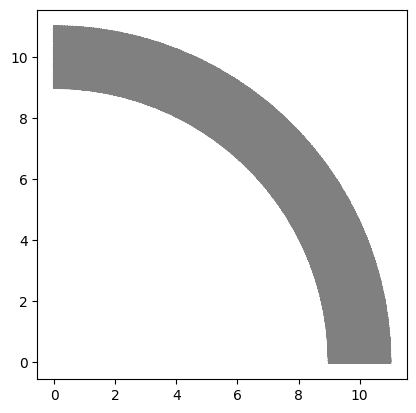

In [ ]:
Re = 11.
Ri = 9.
num_layers = 10  # Número de camadas
# Propriedades dos materiais
E1 = 210e9  # Módulo de Young do material 1 (Pa)
nu1 = 0.3   # Coeficiente de Poisson do material 1
E2 = 70e9   # Módulo de Young do material 2 (Pa)
nu2 = 0.33  # Coeficiente de Poisson do material 2

rect = Rectangle(Point(0., 0.), Point(Re, Re))
domain = Circle(Point(0., 0.), Re, 100) - Circle(Point(0., 0.), Ri, 100)
domain = domain - Rectangle(Point(0., -Re), Point(-2*Re, Re)) \
                - Rectangle(Point(0., 0.), Point(Re, -Re))

mesh = generate_mesh(domain, 100)
plot(mesh)

class Bottom(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0) and on_boundary
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0) and on_boundary
class Outer(SubDomain):
    def inside(self, x, on_boundary):
        return near(sqrt(x[0]**2+x[1]**2), Re, 1e-1) and on_boundary

facets = MeshFunction("size_t", mesh, 1)
facets.set_all(0)
Bottom().mark(facets, 1)
Left().mark(facets, 2)
Outer().mark(facets, 3)
ds = Measure("ds", subdomain_data=facets)

In [ ]:
class MaterialProperties():
    def __init__(self, E1, nu1, E2, nu2, R_inner, R_outer, num_layers, **kwargs):
        #super().__init__(**kwargs)
        self.E1 = E1
        self.nu1 = nu1
        self.E2 = E2
        self.nu2 = nu2
        self.R_inner = R_inner
        self.R_outer = R_outer
        self.num_layers = num_layers

    def eval(self, values, x):
        r = np.sqrt(x[0]**2 + x[1]**2)  # Coordenada radial
        layer_thickness = (self.R_outer - self.R_inner) / self.num_layers
        layer = int((r - self.R_inner) / layer_thickness)
        if layer % 2 == 0:
            values[0] = self.E1
            values[1] = self.nu1
        else:
            values[0] = self.E2
            values[1] = self.nu2

    def value_shape(self):
        return (2,)

material = MaterialProperties(E1, nu1, E2, nu2, Ri, Re, num_layers, degree=0)


In [ ]:
x = SpatialCoordinate(mesh)

def epsilon(u):
    return 0.5*(nabla_grad(u) + nabla_grad(u).T)
    #return sym(nabla_grad(u))

# E = Constant(2e5) #MPa
# nu = Constant(0.3)
# mu = E/2/(1+nu)
# lmbda = E*nu/(1+nu)/(1-2*nu)

def sigma(u):
    E = material[0]
    nu = material[1]
    lmbda = E * nu / ((1 + nu) * (1 - 2 * nu))  # Coeficiente de Lamé para deformação plana
    mu = E / (2 * (1 + nu))  # Coeficiente de Lamé (módulo de cisalhamento)
    return lmbda * tr(epsilon(u)) * Identity(2) + 2 * mu * epsilon(u)

In [ ]:
n = FacetNormal(mesh)
p = Constant(10.)

V = VectorFunctionSpace(mesh, 'CG', degree=2)
du = TrialFunction(V)
u_ = TestFunction(V)
a = inner(sigma(du), eps(u_))*x[0]*dx
l = inner(-p*n, u_)*x[0]*ds(3) #Por que a integração foi feita na superfície externa?

u = Function(V, name="Displacement")

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_f4c31f6e8b0e7ddceb14ce599aa08d063c1bdf82

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00346589 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 1.22501 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_6ab56968c6ffa883272fd990bd40fad8bf858cca

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00244212 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.00832772 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representat

TypeError: 'MaterialProperties' object is not subscriptable

In [ ]:
bcs = [DirichletBC(V.sub(1), Constant(0), facets, 1),
       DirichletBC(V.sub(0), Constant(0), facets, 2)]
solve(a == l, u, bcs)
print("Inwards radial displacement at (r=Re, theta=0): \
{:1.7f} (FE) {:1.7f} (Exact)".format(-u(Re, 0.)[0], float(Re**3/(Re**3-Ri**3)*((1-2*nu)*Re+(1+nu)*Ri**3/2/Re**2)*p/E)))
print("Inwards radial displacement at (r=Ri, theta=0): \
{:1.7f} (FE) {:1.7f} (Exact)".format(-u(Ri, 0.)[0], float(Re**3/(Re**3-Ri**3)*((1-2*nu)*Ri+(1+nu)*Ri/2)*p/E)))

Inwards radial displacement at (r=Re, theta=0): 0.0009276 (FE) 0.0009193 (Exact)
Inwards radial displacement at (r=Ri, theta=0): 0.0010448 (FE) 0.0010447 (Exact)


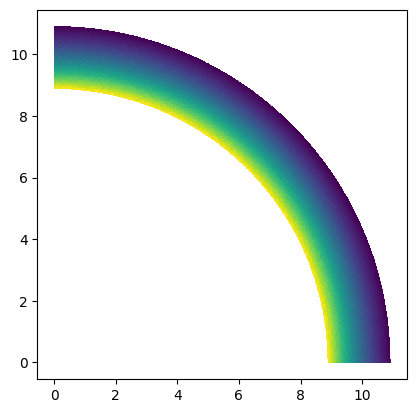

In [ ]:
plt.figure()
plot(100*u, mode="displacement")
plt.show()

In [ ]:
u(Ri, 0.)[0]

-0.0020896792679850804